In [2]:
# Task A1 – Structural Inspection

import pandas as pd
import numpy as np

# Load dataset
file_path = "worldbank_complete_dataset.csv"
df = pd.read_csv(file_path, na_values=[".."])

# To remove unnamed index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [4]:
# Display first few rows
display(df.head())

# 1. Number of rows and columns
rows, cols = df.shape
print(f"Dataset shape: {rows} rows and {cols} columns")

# 2. Data types inferred by pandas
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Pandas Inferred Dtype": df.dtypes.astype(str).values
})

display(dtype_df)

,Country Code,Access to electricity (% of population),Battle-related deaths (number of people),Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e),GDP per capita (constant 2015 US$),"Labor force participation rate, total (% of total population ages 15+) (national estimate)","Life expectancy at birth, total (years)","Mortality rate, infant (per 1,000 live births)",Number of infant deaths,"Population, total",Proportion of seats held by women in national parliaments (%),Income Group,Region
0,ABW,100.000000,NaN,0.0021,31430.935368,NaN,76.353000,NaN,NaN,107359.0,NaN,High income,Latin America & Caribbean
1,AFE,50.667516,NaN,40.6725,1431.721790,NaN,65.146228,41.969085,1021883.0,750491370.0,30.518059,NaN,Africa Eastern and Southern
2,AFG,85.300000,237.0,0.0931,378.066303,NaN,66.035000,49.900000,72559.0,41454761.0,NaN,Low income,Middle East & North Africa
3,AFW,57.069267,9004.0,33.2706,1778.864347,NaN,58.855740,57.353682,959600.0,509398589.0,20.767717,NaN,Africa Western and Central
4,AGO,51.100000,NaN,1.7977,2809.157280,72.207,64.617000,33.000000,44948.0,36749906.0,33.636364,Lower middle income,Sub-Saharan Africa


Dataset shape: 266 rows and 13 columns


,Column,Pandas Inferred Dtype
0,Country Code,object
1,Access to electricity (% of population),float64
2,Battle-related deaths (number of people),float64
3,Carbon dioxide (CO2) emissions from Industrial...,float64
4,GDP per capita (constant 2015 US$),float64
5,"Labor force participation rate, total (% of to...",float64
6,"Life expectancy at birth, total (years)",float64
7,"Mortality rate, infant (per 1,000 live births)",float64
8,Number of infant deaths,float64
9,"Population, total",float64


In [5]:
# 3. Missing values count and percentage for each column
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isna().sum().values,
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2).values
}).sort_values(by="Missing Percentage (%)", ascending=False)

display(missing_df)

,Column,Missing Count,Missing Percentage (%)
2,Battle-related deaths (number of people),208,78.20
5,"Labor force participation rate, total (% of to...",139,52.26
11,Income Group,51,19.17
10,Proportion of seats held by women in national ...,32,12.03
7,"Mortality rate, infant (per 1,000 live births)",22,8.27
8,Number of infant deaths,22,8.27
4,GDP per capita (constant 2015 US$),16,6.02
3,Carbon dioxide (CO2) emissions from Industrial...,15,5.64
1,Access to electricity (% of population),3,1.13
6,"Life expectancy at birth, total (years)",1,0.38


In [6]:
# 4. Number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [8]:
# 5. Identify columns where inferred dtype may be wrong
# We inspect manually based on variable meaning
suspected_wrong_dtype = []

for col in df.columns:
    inferred = str(df[col].dtype)
    
    # Rule-based checks
    if col == "Country Code" and inferred != "object":
        suspected_wrong_dtype.append((col, inferred, "string/category"))
    elif col in ["Income Group", "Region"] and inferred != "object":
        suspected_wrong_dtype.append((col, inferred, "categorical"))
    elif col == "Country Code" and inferred == "object":
        # technically object works, but semantically category/string is more appropriate
        suspected_wrong_dtype.append((col, inferred, "categorical/string"))
    elif col in ["Income Group", "Region"] and inferred == "object":
        suspected_wrong_dtype.append((col, inferred, "categorical"))

wrong_dtype_df = pd.DataFrame(
    suspected_wrong_dtype,
    columns=["Column", "Python Thought", "More Appropriate Type"]
)

display(wrong_dtype_df)

,Column,Python Thought,More Appropriate Type
0,Country Code,object,categorical/string
1,Income Group,object,categorical
2,Region,object,categorical


The dataset was loaded successfully and its structural properties were inspected, including shape, inferred data types, missing values, and duplicate rows. Most development indicator variables were correctly inferred as numeric, while Country Code, Income Group, and Region were inferred as object; semantically, however, Country Code is an identifier and Income Group and Region are categorical variables, so leaving them as generic objects may reduce clarity and lead to less appropriate downstream analysis.

In [11]:
# Task A2 – Variable Classification

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(file_path, na_values=[".."])
df = df.drop(columns=["Unnamed: 0"])

# Create a classification table for each variable
classification_data = []

In [12]:
for col in df.columns:
    dtype = str(df[col].dtype)
    
    # Determine measurement type, role, summary statistic, and visualization
    if col == "Country Code":
        measurement_type = "Nominal Categorical"
        role = "Identifier"
        summary_stat = "Mode (most frequent)"
        visualization = "Bar chart (frequency)"
    
    elif col in ["Income Group", "Region"]:
        measurement_type = "Nominal Categorical"
        role = "True Feature"
        summary_stat = "Frequency table / Mode"
        visualization = "Bar chart / Pie chart"
    
    elif col == "Access to electricity (% of population)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Mean / Median"
        visualization = "Histogram / Box plot"
    
    elif col == "Battle-related deaths (number of people)":
        measurement_type = "Discrete Numerical"
        role = "True Feature"
        summary_stat = "Median / Sum"
        visualization = "Histogram / Bar chart"
    
    elif col == "Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Mean / Median"
        visualization = "Histogram / Box plot"
    
    elif col == "GDP per capita (constant 2015 US$)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Median (due to skewness)"
        visualization = "Histogram / Box plot"
    
    elif col == "Labor force participation rate, total (% of total population ages 15+) (national estimate)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Mean / Median"
        visualization = "Histogram / Box plot"
    
    elif col == "Life expectancy at birth, total (years)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Mean / Median"
        visualization = "Histogram / Box plot"
    
    elif col == "Mortality rate, infant (per 1,000 live births)":
        measurement_type = "Continuous Numerical (Rate)"
        role = "True Feature"
        summary_stat = "Median (sensitive to outliers)"
        visualization = "Histogram / Box plot"
    
    elif col == "Number of infant deaths":
        measurement_type = "Discrete Numerical"
        role = "Derived Field"
        summary_stat = "Median / Sum"
        visualization = "Histogram / Box plot"
    
    elif col == "Population, total":
        measurement_type = "Discrete Numerical"
        role = "True Feature"
        summary_stat = "Median (highly skewed)"
        visualization = "Histogram / Box plot"
    
    elif col == "Proportion of seats held by women in national parliaments (%)":
        measurement_type = "Continuous Numerical"
        role = "True Feature"
        summary_stat = "Mean / Median"
        visualization = "Histogram / Box plot"
    
    classification_data.append({
        "Variable": col,
        "Measurement Type": measurement_type,
        "Role": role,
        "Appropriate Summary Statistic": summary_stat,
        "Appropriate Visualization": visualization
    })

classification_df = pd.DataFrame(classification_data)
display(classification_df)

# Save to CSV for documentation
classification_df.to_csv("variable_classification_table.csv", index=False)
print("\nClassification table saved to 'variable_classification_table.csv'")

,Variable,Measurement Type,Role,Appropriate Summary Statistic,Appropriate Visualization
0,Country Code,Nominal Categorical,Identifier,Mode (most frequent),Bar chart (frequency)
1,Access to electricity (% of population),Continuous Numerical,True Feature,Mean / Median,Histogram / Box plot
2,Battle-related deaths (number of people),Discrete Numerical,True Feature,Median / Sum,Histogram / Bar chart
3,Carbon dioxide (CO2) emissions from Industrial...,Continuous Numerical,True Feature,Mean / Median,Histogram / Box plot
4,GDP per capita (constant 2015 US$),Continuous Numerical,True Feature,Median (due to skewness),Histogram / Box plot
5,"Labor force participation rate, total (% of to...",Continuous Numerical,True Feature,Mean / Median,Histogram / Box plot
6,"Life expectancy at birth, total (years)",Continuous Numerical,True Feature,Mean / Median,Histogram / Box plot
7,"Mortality rate, infant (per 1,000 live births)",Continuous Numerical (Rate),True Feature,Median (sensitive to outliers),Histogram / Box plot
8,Number of infant deaths,Discrete Numerical,Derived Field,Median / Sum,Histogram / Box plot
9,"Population, total",Discrete Numerical,True Feature,Median (highly skewed),Histogram / Box plot



Classification table saved to 'variable_classification_table.csv'


In [14]:
# Task A3 – Missing Data Diagnosis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(file_path, na_values=[".."])
df = df.drop(columns=["Unnamed: 0"])

print("TASK A3 – MISSING DATA DIAGNOSIS")

# 1. NUMERICAL SUMMARY OF MISSINGNESS
print("\n1. NUMERICAL SUMMARY OF MISSINGNESS")

missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing Count": df.isna().sum().values,
    "Total Rows": len(df),
    "Missing %": (df.isna().mean() * 100).round(2).values
}).sort_values(by="Missing %", ascending=False)

display(missing_summary)

# Identify columns with substantial missingness (>5%)
substantial_missing = missing_summary[missing_summary["Missing %"] > 5]
print(f"\nVariables with substantial missingness (>5%): {len(substantial_missing)}")
display(substantial_missing)


TASK A3 – MISSING DATA DIAGNOSIS

1. NUMERICAL SUMMARY OF MISSINGNESS


,Variable,Missing Count,Total Rows,Missing %
2,Battle-related deaths (number of people),208,266,78.20
5,"Labor force participation rate, total (% of to...",139,266,52.26
11,Income Group,51,266,19.17
10,Proportion of seats held by women in national ...,32,266,12.03
7,"Mortality rate, infant (per 1,000 live births)",22,266,8.27
8,Number of infant deaths,22,266,8.27
4,GDP per capita (constant 2015 US$),16,266,6.02
3,Carbon dioxide (CO2) emissions from Industrial...,15,266,5.64
1,Access to electricity (% of population),3,266,1.13
6,"Life expectancy at birth, total (years)",1,266,0.38



Variables with substantial missingness (>5%): 8


,Variable,Missing Count,Total Rows,Missing %
2,Battle-related deaths (number of people),208,266,78.20
5,"Labor force participation rate, total (% of to...",139,266,52.26
11,Income Group,51,266,19.17
10,Proportion of seats held by women in national ...,32,266,12.03
7,"Mortality rate, infant (per 1,000 live births)",22,266,8.27
8,Number of infant deaths,22,266,8.27
4,GDP per capita (constant 2015 US$),16,266,6.02
3,Carbon dioxide (CO2) emissions from Industrial...,15,266,5.64



2. VISUALIZATION OF MISSINGNESS PATTERN


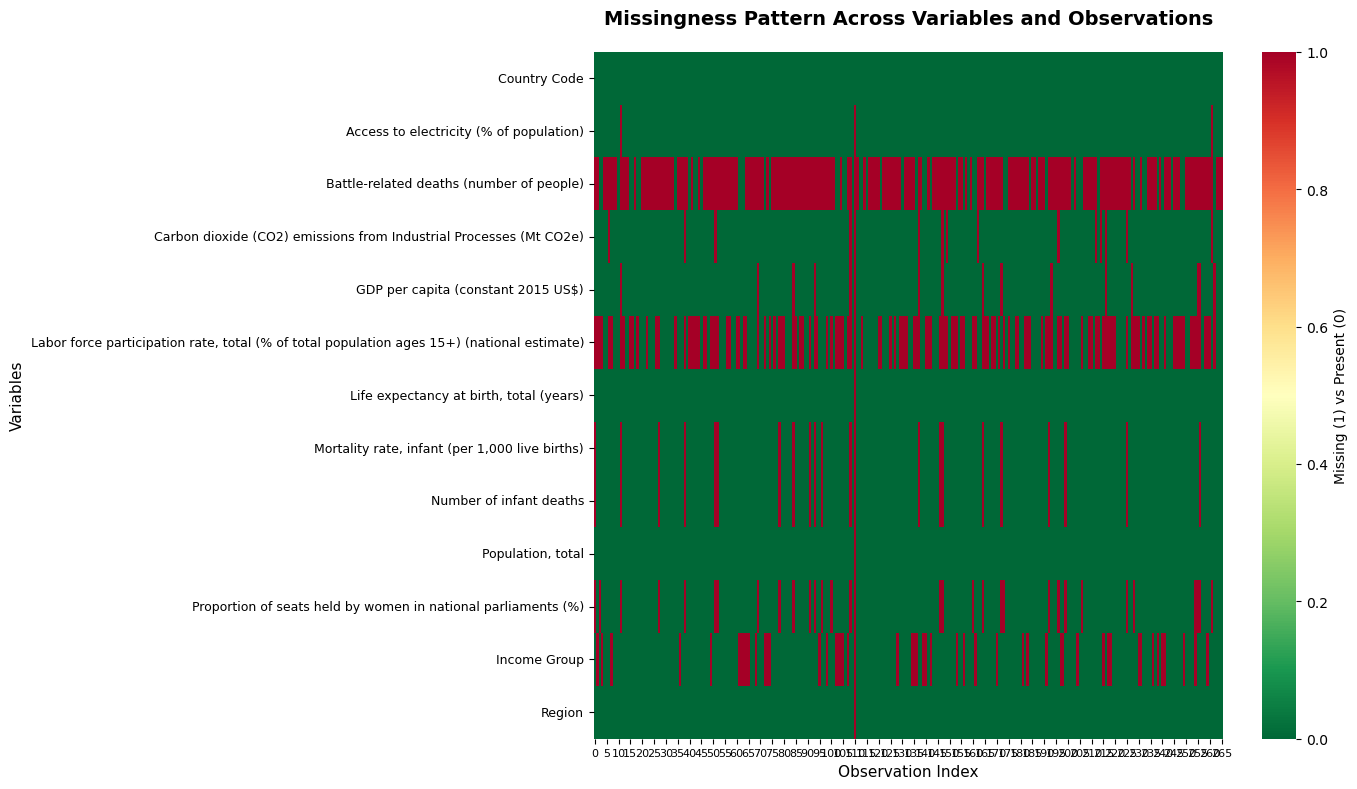


Heatmap saved as 'missingness_heatmap.png'


In [17]:
# 2. VISUALIZATION OF MISSINGNESS PATTERN
print("\n2. VISUALIZATION OF MISSINGNESS PATTERN")

fig, ax = plt.subplots(figsize=(14, 8))
missing_matrix = df.isna().astype(int)

sns.heatmap(missing_matrix.T, 
            cbar=True, 
            cmap='RdYlGn_r',
            yticklabels=df.columns,
            cbar_kws={'label': 'Missing (1) vs Present (0)'},
            ax=ax)

ax.set_title('Missingness Pattern Across Variables and Observations', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Observation Index', fontsize=11)
ax.set_ylabel('Variables', fontsize=11)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('missingness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHeatmap saved as 'missingness_heatmap.png'")

In [19]:
# 3. MISSINGNESS MECHANISM CLASSIFICATION
print("\n3. MISSINGNESS MECHANISM CLASSIFICATION")

missingness_classification = []

# Battle-related deaths (MNAR)
battle_missing = df["Battle-related deaths (number of people)"].isna()
gdp_with_battle = df.loc[~battle_missing, "GDP per capita (constant 2015 US$)"].mean()
gdp_without_battle = df.loc[battle_missing, "GDP per capita (constant 2015 US$)"].mean()

print("\nBattle-related deaths (78.2% missing): MNAR")
print(f"  Countries WITH battle data: {(~battle_missing).sum()}")
print(f"  Average GDP (with data): ${gdp_with_battle:,.2f}")
print(f"  Average GDP (without data): ${gdp_without_battle:,.2f}")

missingness_classification.append({
    "Variable": "Battle-related deaths",
    "Missing %": 78.2,
    "Mechanism": "MNAR",
    "Reasoning": "Missingness directly related to value—countries without conflicts have no deaths to report"
})

# Labor force participation rate (MAR)
labor_missing = df["Labor force participation rate, total (% of total population ages 15+) (national estimate)"].isna()
income_labor_missing = df.groupby("Income Group")["Labor force participation rate, total (% of total population ages 15+) (national estimate)"].apply(lambda x: x.isna().mean() * 100)

print("\nLabor force participation rate (52.3% missing): MAR")
print("  Missingness rate by Income Group:")
print(income_labor_missing.round(2))

missingness_classification.append({
    "Variable": "Labor force participation rate",
    "Missing %": 52.3,
    "Mechanism": "MAR",
    "Reasoning": "Missingness varies by Income Group—linked to data infrastructure"
})

# Income Group (MAR)
income_missing = df["Income Group"].isna()
print(f"\nIncome Group (19.2% missing): MAR")
print(f"  Missing occurs systematically for regional aggregates, not countries")

missingness_classification.append({
    "Variable": "Income Group",
    "Missing %": 19.2,
    "Mechanism": "MAR",
    "Reasoning": "Missing for regional aggregates (not individual countries)"
})

# GDP per capita (MAR)
missingness_classification.append({
    "Variable": "GDP per capita",
    "Missing %": 6.0,
    "Mechanism": "MAR",
    "Reasoning": "Missing for specific entity types (territories, special regions)"
})

classification_summary = pd.DataFrame(missingness_classification)
display(classification_summary)


3. MISSINGNESS MECHANISM CLASSIFICATION

Battle-related deaths (78.2% missing): MNAR
  Countries WITH battle data: 58
  Average GDP (with data): $5,053.90
  Average GDP (without data): $19,839.90

Labor force participation rate (52.3% missing): MAR
  Missingness rate by Income Group:
Income Group
High income            37.21
Low income             84.00
Lower middle income    58.00
Upper middle income    40.74
Name: Labor force participation rate, total (% of total population ages 15+) (national estimate), dtype: float64

Income Group (19.2% missing): MAR
  Missing occurs systematically for regional aggregates, not countries


,Variable,Missing %,Mechanism,Reasoning
0,Battle-related deaths,78.2,MNAR,Missingness directly related to value—countrie...
1,Labor force participation rate,52.3,MAR,Missingness varies by Income Group—linked to d...
2,Income Group,19.2,MAR,Missing for regional aggregates (not individua...
3,GDP per capita,6.0,MAR,Missing for specific entity types (territories...


In [20]:
# 4. COMPARISON OF IMPUTATION STRATEGIES
print("\n4. COMPARISON OF IMPUTATION STRATEGIES")

print("\nVariable: GDP per capita (constant 2015 US$) [6.02% missing]")


# Original statistics
gdp_original = df["GDP per capita (constant 2015 US$)"].dropna()
original_mean = gdp_original.mean()
original_std = gdp_original.std()
original_median = gdp_original.median()

print(f"\nORIGINAL (listwise deletion):")
print(f"  Mean:   ${original_mean:,.2f}")
print(f"  Median: ${original_median:,.2f}")
print(f"  Std Dev: ${original_std:,.2f}")
print(f"  N = {len(gdp_original)}")

# Median imputation
df_median_imputed = df.copy()
df_median_imputed["GDP per capita (constant 2015 US$)"] = df_median_imputed["GDP per capita (constant 2015 US$)"].fillna(original_median)

median_imp_mean = df_median_imputed["GDP per capita (constant 2015 US$)"].mean()
median_imp_std = df_median_imputed["GDP per capita (constant 2015 US$)"].std()

print(f"\nMEDIAN IMPUTATION:")
print(f"  Mean:   ${median_imp_mean:,.2f}")
print(f"  Median: ${original_median:,.2f}")
print(f"  Std Dev: ${median_imp_std:,.2f}")
print(f"  N = {len(df_median_imputed)}")

# Mean imputation
df_mean_imputed = df.copy()
df_mean_imputed["GDP per capita (constant 2015 US$)"] = df_mean_imputed["GDP per capita (constant 2015 US$)"].fillna(original_mean)

mean_imp_mean = df_mean_imputed["GDP per capita (constant 2015 US$)"].mean()
mean_imp_std = df_mean_imputed["GDP per capita (constant 2015 US$)"].std()

print(f"\nMEAN IMPUTATION:")
print(f"  Mean:   ${mean_imp_mean:,.2f}")
print(f"  Median: ${df_mean_imputed['GDP per capita (constant 2015 US$)'].median():,.2f}")
print(f"  Std Dev: ${mean_imp_std:,.2f}")
print(f"  N = {len(df_mean_imputed)}")

# Comparison table
comparison_df = pd.DataFrame({
    "Strategy": ["Listwise Deletion", "Median Imputation", "Mean Imputation"],
    "Mean": [original_mean, median_imp_mean, mean_imp_mean],
    "Std Dev": [original_std, median_imp_std, mean_imp_std],
    "Δ Mean (%)": [0, ((median_imp_mean - original_mean) / original_mean * 100), 0],
    "Δ Std (%)": [0, ((median_imp_std - original_std) / original_std * 100), 
                  ((mean_imp_std - original_std) / original_std * 100)]
})

display(comparison_df)


4. COMPARISON OF IMPUTATION STRATEGIES

Variable: GDP per capita (constant 2015 US$) [6.02% missing]

ORIGINAL (listwise deletion):
  Mean:   $16,527.84
  Median: $6,471.28
  Std Dev: $24,601.00
  N = 250

MEDIAN IMPUTATION:
  Mean:   $15,922.93
  Median: $6,471.28
  Std Dev: $23,966.80
  N = 266

MEAN IMPUTATION:
  Mean:   $16,527.84
  Median: $7,351.24
  Std Dev: $23,846.77
  N = 266


,Strategy,Mean,Std Dev,Δ Mean (%),Δ Std (%)
0,Listwise Deletion,16527.837167,24601.003789,0.000000,0.000000
1,Median Imputation,15922.931301,23966.797435,-3.659921,-2.577969
2,Mean Imputation,16527.837167,23846.770081,0.000000,-3.065866
